|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 4:</h2>|<h1>The Scheduler<h1>|
|<h2>Section:</h2>|<h1>Chunked prefill<h1>|
|<h2>Lecture:</h2>|<h1><b>One long prompt stops the whole server<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# One long prompt stops the whole server

Thirty-two users are decoding happily, a token every ten milliseconds. Then
somebody pastes in eight thousand tokens.

That prefill has to run. While it runs, nobody else gets a token.

In [2]:
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()

@torch.inference_mode()
def step_ms(n_tokens):
  """What one forward pass costs, for a step holding n_tokens in total."""
  x = torch.randint(0, 1000, (1, n_tokens), device='cuda')
  return cudalib.bench_ms(lambda: model(x, use_cache=False, logits_to_keep=1),
                          iters=8, warmup=3, best_of=2)

budgets = [32, 64, 128, 256, 512, 1024, 2048, 4096]
ms = np.array([step_ms(n) for n in budgets])

print(f"{'tokens in the step':>19} {'ms':>8} {'ms per token':>13}")
for n, t in zip(budgets, ms):
  print(f'{n:>19} {t:>8.2f} {t/n:>13.4f}')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 14724.00it/s]

 tokens in the step       ms  ms per token
                 32    14.45        0.4516
                 64    53.92        0.8426
                128    41.99        0.3281
                256    27.97        0.1092
                512    29.91        0.0584
               1024    54.50        0.0532
               2048   118.62        0.0579
               4096   290.35        0.0709


### Two regimes in one table

Up to a couple of hundred tokens the step costs the same as a step with
thirty-two: you are paying to read the weights and the tokens ride along
free. That is the memory-bound half of Part 1's roofline.

Past that it goes linear, and you are paying per token. That is the
compute-bound half.

The number where it bends is the one the scheduler needs.

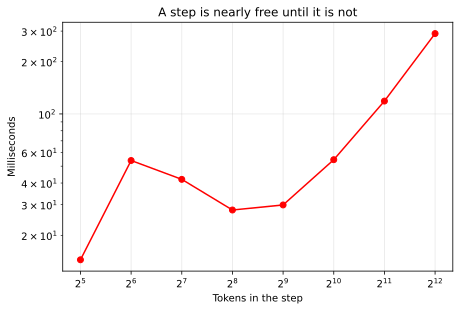

a step is essentially free up to about 32 tokens


In [3]:
plt.figure(figsize=(7,4.5))
plt.plot(budgets, ms, 'ro-')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('Tokens in the step'); plt.ylabel('Milliseconds')
plt.title('A step is nearly free until it is not')
plt.grid(alpha=.3); plt.show()

flat = [n for n,t in zip(budgets,ms) if t < 1.3*ms[0]]
print(f'a step is essentially free up to about {max(flat)} tokens')

# What that does to everyone else

Call the decode batch 32 sequences, so a plain decode step holds 32 tokens.
Now put an 8192-token prefill in the same batch.

In [4]:
decode_only = step_ms(32)
stalled     = step_ms(4096)     # the biggest that fits comfortably here

print(f'a normal decode step:        {decode_only:7.2f} ms')
print(f'the step with the prefill:   {stalled:7.2f} ms')
print(f'\nevery one of the 32 users waits {stalled/decode_only:.0f}x longer for that token')

a normal decode step:          21.47 ms
the step with the prefill:    314.18 ms

every one of the 32 users waits 15x longer for that token


### Now chop the prefill up

Nothing says the prefill must finish in one step. Feed it `chunk` tokens at a
time, alongside the decodes, and it takes several steps to complete while
nobody is ever stalled for long.

This is Sarathi-Serve, and it is the throughput/latency dial in every modern
serving stack.

In [5]:
PREFILL = 4096
DECODES = 32

print(f"{'chunk':>7} {'steps to prefill':>17} {'ms per step':>12} {'worst wait':>11}")
rows = []
for chunk in (128, 256, 512, 1024, 2048, 4096):
  per_step = step_ms(DECODES + chunk)
  nsteps   = int(np.ceil(PREFILL/chunk))
  rows.append((chunk, nsteps, per_step))
  print(f'{chunk:>7} {nsteps:>17} {per_step:>11.2f}ms {per_step:>10.2f}ms')

  chunk  steps to prefill  ms per step  worst wait


    128                32       21.54ms      21.54ms


    256                16       20.08ms      20.08ms


    512                 8       35.52ms      35.52ms


   1024                 4       71.01ms      71.01ms


   2048                 2      147.12ms     147.12ms


   4096                 1      337.40ms     337.40ms


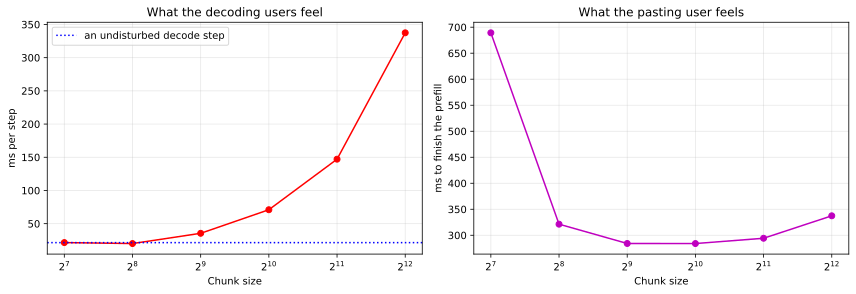

In [6]:
r = np.array(rows, dtype=float)
total = r[:,1] * r[:,2]

fig, axs = plt.subplots(1,2, figsize=(12,4.2))
axs[0].plot(r[:,0], r[:,2], 'ro-')
axs[0].axhline(decode_only, color='b', ls=':', label='an undisturbed decode step')
axs[0].set_xscale('log', base=2)
axs[0].set(xlabel='Chunk size', ylabel='ms per step',
           title='What the decoding users feel')
axs[0].legend(); axs[0].grid(alpha=.3)

axs[1].plot(r[:,0], total, 'mo-')
axs[1].set_xscale('log', base=2)
axs[1].set(xlabel='Chunk size', ylabel='ms to finish the prefill',
           title='What the pasting user feels')
axs[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [7]:
print(f"{'chunk':>7} {'ITL for the 32':>15} {'TTFT for the 1':>15}")
for (chunk, nsteps, per_step), tot in zip(rows, total):
  print(f'{chunk:>7} {per_step:>14.1f}ms {tot:>14.1f}ms')
print(f'\nunchunked, the 32 wait {stalled:.0f} ms for one token.')
print(f'at chunk 256 they wait {rows[1][2]:.0f} ms, and the prefill takes '
      f'{total[1]/total[-1]:.1f}x longer to finish.')

  chunk  ITL for the 32  TTFT for the 1
    128           21.5ms          689.3ms
    256           20.1ms          321.3ms
    512           35.5ms          284.2ms
   1024           71.0ms          284.0ms
   2048          147.1ms          294.2ms
   4096          337.4ms          337.4ms

unchunked, the 32 wait 314 ms for one token.
at chunk 256 they wait 20 ms, and the prefill takes 1.0x longer to finish.


### The dial, stated plainly

- **Small chunks**: the decoding users barely notice. The long prompt takes
  longer to start producing, because each step carries less of it and each
  step still pays to read the weights.
- **Large chunks**: the prefill finishes as fast as the hardware allows, and
  every other user feels it.

There is no setting that is best for both, which is why this is exposed as a
configuration value in real engines rather than decided for you. What you can
do is refuse to be stupid about it: the left half of the first plot showed a
step is nearly free up to a couple of hundred tokens, so a chunk below that
size buys latency you were not going to feel and costs throughput you were.

The modern form of this idea goes further. vLLM V1 dropped the distinction
between prefill steps and decode steps entirely. There is a **token budget**
per step, and a request contributes however many tokens it needs, whether
that is one continuation token or a slice of a prompt.

    ./vc guide 11